<a href="https://colab.research.google.com/github/huonggnguyen-source/AIHC-5020/blob/main/Final_exam_AIHC5020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
data = [
    {
        "name": "Integer",
        "python_symbol": "int",
        "example": str(25),
        "falsy_value": str(0),
        "usage": "Represents whole numbers without a fractional component.",
    },
    {
        "name": "Floating Point",
        "python_symbol": "float",
        "example": str(3.14),
        "falsy_value": str(0.0),
        "usage": "Represents real numbers with fractional/decimal components.",
    },
    {
        "name": "Complex Number",
        "python_symbol": "complex",
        "example": str(1 + 2j),
        "falsy_value": str(0j),
        "usage": "Represents numbers with real and imaginary parts.",
    },
    {
        "name": "Boolean",
        "python_symbol": "bool",
        "example": str(True),
        "falsy_value": str(False),
        "usage": "Represents truth values used in logical operations.",
    },
    {
        "name": "String",
        "python_symbol": "str",
        "example": str("Hello"),
        "falsy_value": repr(""),
        "usage": "Represents ordered, immutable sequences of text characters.",
    },
    {
        "name": "Bytes",
        "python_symbol": "bytes",
        "example": str(b"bytes"),
        "falsy_value": repr(b""),
        "usage": "Represents immutable sequences of raw 8-bit bytes.",
    },
    {
        "name": "List",
        "python_symbol": "list",
        "example": str([1, 2, 3]),
        "falsy_value": str([]),
        "usage": "Represents ordered, mutable collections of items.",
    },
    {
        "name": "Tuple",
        "python_symbol": "tuple",
        "example": str((1, 2, 3)),
        "falsy_value": str(()),
        "usage": "Represents ordered, immutable collections of items.",
    },
    {
        "name": "Dictionary",
        "python_symbol": "dict",
        "example": str({"a": 1, "b": 2}),
        "falsy_value": str({}),
        "usage": "Represents unordered/insertion-ordered, mutable mappings of key-value pairs.",
    },
]

df = pd.DataFrame(data)

df

,name,python_symbol,example,falsy_value,usage
0,Integer,int,25,0,Represents whole numbers without a fractional ...
1,Floating Point,float,3.14,0.0,Represents real numbers with fractional/decima...
2,Complex Number,complex,(1+2j),0j,Represents numbers with real and imaginary parts.
3,Boolean,bool,True,False,Represents truth values used in logical operat...
4,String,str,Hello,'',"Represents ordered, immutable sequences of tex..."
5,Bytes,bytes,b'bytes',b'',Represents immutable sequences of raw 8-bit by...
6,List,list,"[1, 2, 3]",[],"Represents ordered, mutable collections of items."
7,Tuple,tuple,"(1, 2, 3)",(),"Represents ordered, immutable collections of i..."
8,Dictionary,dict,"{'a': 1, 'b': 2}",{},"Represents unordered/insertion-ordered, mutabl..."


In [3]:
#2Problem 2: Chat Log Data

In [4]:
from datetime import datetime
import json
from google.cloud import storage
import pandas as pd


def load_chat_log_dataframe(chat_id: int):
    """Downloads a chat log JSON file from Google Cloud Storage for a given chat_id

    and returns it as a log table format time series Pandas DataFrame.
    """
    bucket_name = "cloud-samples-data"
    prefix = "ccai/sample-chat-logs"


    client = storage.Client.create_anonymous_client()
    bucket = client.bucket(bucket_name)


    blobs = list(bucket.list_blobs(prefix=prefix))
    target_blob = None

    for blob in blobs:
        # Match filenames like '.../chat-log-101.json' or '.../101.json'
        if f"-{chat_id}.json" in blob.name or blob.name.endswith(
            f"/{chat_id}.json"
        ):
            target_blob = blob
            break

    if target_blob is None:
        print(f"No chat log file found for integer id: {chat_id}")
        return None

    content = target_blob.download_as_text()
    data = json.loads(content)


    messages = data if isinstance(data, list) else data.get("messages", [])

    records = []
    for msg in messages:

        timestamp_us = msg.get("timestamp") or msg.get("time") or 0
        timestamp_dt = datetime.utcfromtimestamp(timestamp_us / 1e6)
        formatted_time = timestamp_dt.strftime("%Y-%m-%d %H:%M:%S")

        records.append(
            {
                "timestamp": formatted_time,
                "sender": msg.get("sender") or msg.get("author"),
                "text": msg.get("text") or msg.get("content"),
            }
        )

    df = pd.DataFrame(records)
    return df



df_101 = load_chat_log_dataframe(101)


if df_101 is not None:
    print(df_101)

No chat log file found for integer id: 101


In [7]:
from google.cloud import storage

client = storage.Client.create_anonymous_client()
blobs = list(client.list_blobs("cloud-samples-data", prefix="ccai/sample-chat-logs"))

for blob in blobs:
    if "101" in blob.name:
        print("Found file:", blob.name)
        print("Raw JSON Content sample:")
        print(blob.download_as_text()[:500])
        break

Found file: ccai/sample-chat-logs/chat_101.json
Raw JSON Content sample:
{
    "entries": [
        {
            "start_timestamp_usec": 1677118060000000,
            "text": "Hello, how can I assist you today?",
            "role": "AGENT",
            "user_id": 2
        },
        {
            "start_timestamp_usec": 1677118078000000,
            "text": "Hi, I'm having an issue with my laptop",
            "role": "CUSTOMER",
            "user_id": 1
        },
        {
            "start_timestamp_usec": 1677118096000000,
            "text": "Sorry to hear. 


In [8]:
from datetime import datetime, timezone
import json
from google.cloud import storage
import pandas as pd


def load_chat_log_dataframe(chat_id: int):
    """Downloads a chat log JSON file from Google Cloud Storage for a given chat_id

    and returns it as a log table format time series Pandas DataFrame.
    """
    bucket_name = "cloud-samples-data"
    prefix = "ccai/sample-chat-logs"


    client = storage.Client.create_anonymous_client()
    bucket = client.bucket(bucket_name)


    blobs = list(client.list_blobs(bucket_name, prefix=prefix))
    target_blob = None

    for blob in blobs:
        filename = blob.name.split("/")[-1]
        digits = "".join(filter(str.isdigit, filename))
        if digits and int(digits) == chat_id:
            target_blob = blob
            break

    if target_blob is None:
        print(f"No chat log file found for integer id: {chat_id}")
        return None

    content = target_blob.download_as_text()
    data = json.loads(content)


    messages = []
    if isinstance(data, list):
        messages = data
    elif isinstance(data, dict):

        for key in ["messages", "transcript", "entries", "logs", "events"]:
            if key in data and isinstance(data[key], list):
                messages = data[key]
                break
        if not messages and "turns" in data:
            messages = data["turns"]

    if not messages:
        print(f"No message entries found in file for integer id: {chat_id}")
        return pd.DataFrame()

    records = []
    for msg in messages:

        raw_ts = (
            msg.get("timestampUsec")
            or msg.get("timestamp")
            or msg.get("time")
            or msg.get("sendTime")
        )


        if raw_ts is None and "payload" in msg:
            raw_ts = msg["payload"].get("timestamp")

        if raw_ts is None:
            continue


        ts_float = float(raw_ts)

        if ts_float < 1e11:
            ts_float *= 1e6

        dt = datetime.fromtimestamp(ts_float / 1_000_000, tz=timezone.utc)
        formatted_time = dt.strftime("%Y-%m-%d %H:%M:%S")


        sender = (
            msg.get("sender")
            or msg.get("role")
            or msg.get("author")
            or msg.get("speaker")
            or "unknown"
        )
        if isinstance(sender, dict):
            sender = sender.get("role") or sender.get("name") or "unknown"

        text = (
            msg.get("text")
            or msg.get("content")
            or msg.get("message")
            or msg.get("transcript")
            or ""
        )

        records.append(
            {"timestamp": formatted_time, "sender": sender, "text": text}
        )

    return pd.DataFrame(records)


df_101 = load_chat_log_dataframe(101)
print(df_101)

Empty DataFrame
Columns: []
Index: []


In [9]:
import json
from google.cloud import storage

client = storage.Client.create_anonymous_client()
bucket = client.bucket("cloud-samples-data")

# Find the exact blob for ID 101
blobs = list(client.list_blobs("cloud-samples-data", prefix="ccai/sample-chat-logs"))
blob_101 = next(b for b in blobs if "101" in b.name)

raw_data = json.loads(blob_101.download_as_text())

print("--- RAW JSON STRUCTURE DEBUG ---")
print("Top-level type:", type(raw_data))
if isinstance(raw_data, dict):
    print("Top-level keys:", list(raw_data.keys()))
elif isinstance(raw_data, list) and len(raw_data) > 0:
    print("First item keys:", list(raw_data[0].keys()))
print("\nFirst 300 characters of raw string:")
print(blob_101.download_as_text()[:300])

--- RAW JSON STRUCTURE DEBUG ---
Top-level type: <class 'dict'>
Top-level keys: ['entries']

First 300 characters of raw string:
{
    "entries": [
        {
            "start_timestamp_usec": 1677118060000000,
            "text": "Hello, how can I assist you today?",
            "role": "AGENT",
            "user_id": 2
        },
        {
            "start_timestamp_usec": 1677118078000000,
            "text": "Hi, I'm h


In [10]:
from datetime import datetime, timezone
import json
from google.cloud import storage
import pandas as pd


def load_chat_log_dataframe(chat_id: int):
    """Downloads a chat log JSON file from Google Cloud Storage for a given chat_id

    and returns it as a log table format time series Pandas DataFrame.
    """
    bucket_name = "cloud-samples-data"
    prefix = "ccai/sample-chat-logs"


    client = storage.Client.create_anonymous_client()


    blobs = list(client.list_blobs(bucket_name, prefix=prefix))
    target_blob = None

    for blob in blobs:
        filename = blob.name.split("/")[-1]
        digits = "".join(filter(str.isdigit, filename))
        if digits and int(digits) == chat_id:
            target_blob = blob
            break


    if target_blob is None:
        print(f"No chat log file found for integer id: {chat_id}")
        return None


    content = target_blob.download_as_text()
    data = json.loads(content)


    entries = data.get("entries", [])
    if not entries and isinstance(data, list):
        entries = data

    records = []
    for entry in entries:

        ts_usec = (
            entry.get("start_timestamp_usec")
            or entry.get("timestamp_usec")
            or entry.get("timestamp")
            or 0
        )


        dt = datetime.fromtimestamp(float(ts_usec) / 1_000_000, tz=timezone.utc)
        formatted_time = dt.strftime("%Y-%m-%d %H:%M:%S")

        sender = entry.get("role") or entry.get("sender") or "UNKNOWN"
        text = entry.get("text") or entry.get("content") or ""

        records.append(
            {"timestamp": formatted_time, "role": sender, "text": text}
        )


    df = pd.DataFrame(records)
    return df


df_101 = load_chat_log_dataframe(101)


if df_101 is not None:
    print(df_101)

              timestamp      role  \
0   2023-02-23 02:07:40     AGENT   
1   2023-02-23 02:07:58  CUSTOMER   
2   2023-02-23 02:08:16     AGENT   
3   2023-02-23 02:08:34  CUSTOMER   
4   2023-02-23 02:08:52     AGENT   
5   2023-02-23 02:09:10  CUSTOMER   
6   2023-02-23 02:09:28     AGENT   
7   2023-02-23 02:09:46  CUSTOMER   
8   2023-02-23 02:10:04     AGENT   
9   2023-02-23 02:10:22  CUSTOMER   
10  2023-02-23 02:10:40     AGENT   
11  2023-02-23 02:10:58  CUSTOMER   
12  2023-02-23 02:11:16     AGENT   
13  2023-02-23 02:11:34  CUSTOMER   

                                                 text  
0                  Hello, how can I assist you today?  
1              Hi, I'm having an issue with my laptop  
2   Sorry to hear. Can you tell me what the proble...  
3   The laptop is not connecting to the internet. ...  
4   Can you give me more details about the problem...  
5   The problem with the laptop is still happening...  
6   And what is the status shown in the settings o..

In [11]:
# Problem 3: Chest X-ray DICOM manifest

In [16]:
!pip install pydicom

In [18]:
import os
import pandas as pd


try:
    import pydicom
except ImportError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "pydicom"])
    import pydicom

try:
    from google.colab import drive

    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
except Exception:
    pass

dicom_dir = "/content/drive/MyDrive/AIHC5020/dicom/chest_xray"


# 4. Diagnostic Check: Verify directory existence and list found files
if not os.path.exists(dicom_dir):
    print(f"❌ DIRECTORY NOT FOUND: '{dicom_dir}'")
    print("Please check your Google Drive folder structure and spelling.")
else:
    all_files = []
    for root, _, files in os.walk(dicom_dir):
        for f in files:
            all_files.append(os.path.join(root, f))

    print(f"📁 Path exists! Found {len(all_files)} total files in directory.")

def generate_dicom_manifest(folder_path: str) -> pd.DataFrame:
    series_map = {}

    for root, _, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)

            try:

                ds = pydicom.dcmread(
                    file_path, stop_before_pixels=True, force=True
                )


                series_uid = getattr(ds, "SeriesInstanceUID", None)
                if not series_uid:

                    series_uid = f"series_{os.path.basename(root)}"

                if series_uid not in series_map:
                    study_uid = str(getattr(ds, "StudyInstanceUID", "N/A"))
                    patient_id = str(getattr(ds, "PatientID", "N/A"))
                    study_date = str(getattr(ds, "StudyDate", "N/A"))
                    modality = str(getattr(ds, "Modality", "N/A"))


                    if len(study_date) == 8 and study_date.isdigit():
                        study_date = f"{study_date[:4]}-{study_date[4:6]}-{study_date[6:]}"

                    series_map[series_uid] = {
                        "series_uid": str(series_uid),
                        "study_uid": study_uid,
                        "patient_id": patient_id,
                        "study_date": study_date,
                        "modality": modality,
                        "num_images": 0,
                        "series_directory": root,
                    }

                series_map[series_uid]["num_images"] += 1

            except Exception as e:

                continue

    return pd.DataFrame(list(series_map.values()))


manifest_df = generate_dicom_manifest(dicom_dir)

print("\n--- DICOM Manifest Summary ---")
print(f"Total DICOM Series Found: {len(manifest_df)}")
manifest_df.head()

Mounted at /content/drive
📁 Path exists! Found 75 total files in directory.

--- DICOM Manifest Summary ---
Total DICOM Series Found: 35


,series_uid,study_uid,patient_id,study_date,modality,num_images,series_directory
0,series_chest_xray,N/A,N/A,N/A,N/A,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xray
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.140111454550...,1.3.6.1.4.1.14519.5.2.1.6279.6001.213083367261...,LIDC-IDRI-0015,2000-01-01,DX,1,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.541650212189...,1.3.6.1.4.1.14519.5.2.1.6279.6001.675114969651...,LIDC-IDRI-0023,2000-01-01,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.334422875695...,1.3.6.1.4.1.14519.5.2.1.6279.6001.302822025885...,LIDC-IDRI-0040,2000-01-01,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
4,series_LIDC-IDRI-0014,N/A,N/A,N/A,N/A,1,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...


In [19]:
#4 Problem 4: Visualizing Chest X-Rays

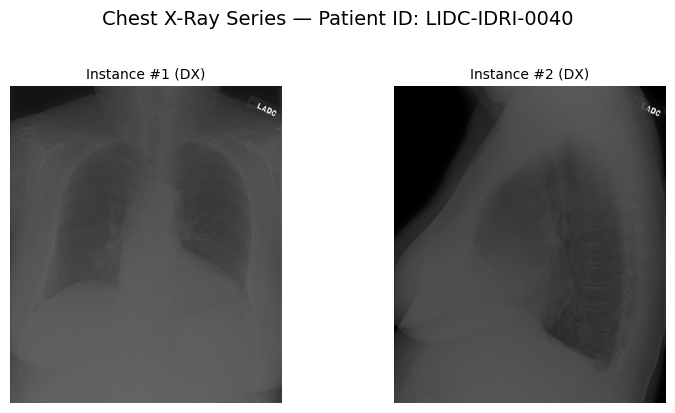

In [20]:
import os
import math
import matplotlib.pyplot as plt
import pandas as pd
import pydicom

def display_patient_series(patient_id: str, manifest_df: pd.DataFrame):
    """
    Finds all DICOM series for a specified patient_id, loads their image frames,
    and plots them adaptively in a single Matplotlib figure.
    """

    patient_series = manifest_df[manifest_df['patient_id'] == patient_id]

    if patient_series.empty:
        print(f"Patient ID '{patient_id}' not found in the provided manifest.")
        return None


    image_files = []
    for _, row in patient_series.iterrows():
        series_dir = row['series_directory']
        if os.path.exists(series_dir):
            for file in os.listdir(series_dir):
                file_path = os.path.join(series_dir, file)
                try:
                    # Check if valid DICOM file
                    ds = pydicom.dcmread(file_path, stop_before_pixels=True, force=True)
                    if getattr(ds, 'PatientID', None) == patient_id:
                        image_files.append(file_path)
                except Exception:
                    continue

    if not image_files:
        print(f"No valid DICOM image files found on disk for patient '{patient_id}'.")
        return None

    num_images = len(image_files)


    cols = min(num_images, 4)
    rows = math.ceil(num_images / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
    axes_flat = axes.flatten()


    for idx, img_path in enumerate(image_files):
        try:
            ds = pydicom.dcmread(img_path, force=True)
            pixel_array = ds.pixel_array


            ax = axes_flat[idx]
            ax.imshow(pixel_array, cmap='gray')

            instance_num = getattr(ds, 'InstanceNumber', idx + 1)
            modality = getattr(ds, 'Modality', '')
            ax.set_title(f"Instance #{instance_num} ({modality})", fontsize=10)
            ax.axis('off')
        except Exception as e:
            axes_flat[idx].text(0.5, 0.5, f"Error loading\n{os.path.basename(img_path)}",
                                ha='center', va='center')
            axes_flat[idx].axis('off')

    for idx in range(num_images, len(axes_flat)):
        axes_flat[idx].axis('off')

    fig.suptitle(f"Chest X-Ray Series — Patient ID: {patient_id}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
display_patient_series("LIDC-IDRI-0040", manifest_df)